In [2]:
import sys
import os
import numpy as np
import pandas as pd
import pickle
import psutil
# sys.path.append('/home/gridsan/jmaalouf/vHTP/Code/DFT/DFT_script_gen')
#sys.path.insert(1,'/home2/gridsan/jmaalouf/vHTP/Code/Utils')
sys.path.insert(1,'/data1/gridsan/groups/manthiram_lab/Utils')
sys.path.insert(1,'/data1/gridsan/groups/manthiram_lab/DFT/DFT_script_gen')

import utils
from utils import make_xyz_from_array, GetCoordsFromMolBlock
import xyz2mol as x2m
import re
import importlib
from tqdm import tqdm
import shutil
import convertxyz
import DFT_Script_gen
import subprocess
import glob

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.rdchem import Mol
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D,MolToImage,ShowMol
from mksmifile import mk_smi_file
from DFT_Script_gen import mkgauss_input_from_xyz,mkgauss_submission_script
from convertxyz import mk_xyz_from_smiles_string, get_xyz_from_mol, write_xyz_from_xyz_arr

In [25]:
importlib.reload(utils)
importlib.reload(x2m)
importlib.reload(convertxyz)
importlib.reload(DFT_Script_gen)

<module 'DFT_Script_gen' from '/data1/gridsan/groups/manthiram_lab/DFT/DFT_script_gen/DFT_Script_gen.py'>

In [26]:
df=pd.read_csv('sheets/Ylides_YlideRads_Cleaned.csv')
y=df['Ylides'].to_list()
yr=df['Ylides Rad'].to_list()
yh=df['Ylides H'].to_list()

In [7]:
# for suff in suffix:
#     for i in range(9):
#         srcpath=f'{cwd}/Calcs_solv/{str(i).zfill(z)}/ylide{suff}/{str(i).zfill(z)}_ylide{suff}.log'
#         destpath=f'{cwd}/Calcs/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvmethod}/{solvent}/{str(i).zfill(z)}_ylide{suff}.log'

#         shutil.copy(srcpath,destpath)
    

## Generate Directories and Scripts

### Make Gas Phase Scripts

In [ ]:
actually_make_dirs=True
if actually_make_dirs:

    z=7
    cwd=os.getcwd()
    calc_folder='Calcs'
    #for i, s in enumerate(tqdm(y)):

    functional='M062X'
    basis= 'Def2TZVP'
    solvorgas='gas' #This should only be used for gas phase, since we need the gas phase pre opt for solv
    solvmethod='SMD'
    solvent='acetonitrile'
    cwd='/data1/gridsan/jmaalouf/vHTP/Code/ylide/Library'
    shared_dir='/data1/gridsan/groups/manthiram_lab/vHTP/Code/ylide/Library/Calcs'
    
    for i, s in enumerate(tqdm(range(1000,10000))):

        assert solvorgas == 'gas' or solvorgas=='solv','SOLVORGAS NOT SET TO A VALID VALUE'

        suffix= ['','_h',] #For solv gase you probably dont need _rad 
        
        smi_dict={
        ''     : y,
        '_rad' : yr,
        '_h'   : yh
         }
        
        for j, suff in enumerate(suffix): 


            if solvorgas=='gas':

                #basepath=f'{cwd}/{calc_folder}/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/gas'
                basepath=f'{shared_dir}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/gas/'

            elif solvorgas=='solv':

                try:
                    solvent
                except NameError:
                    raise Exception('PLEASE SPECIFY A SOLVENT')


                #basepath=f'{cwd}/{calc_folder}/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/{solvmethod}'
                basepath=f'{shared_dir}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/{solvmethod}/'
                
            #os.chdir(shared_dir)
            os.makedirs(basepath,exist_ok=True)
            #os.chdir(cwd)

            smi= smi_dict[suff][s]
            path=f'{basepath}/{str(s).zfill(z)}_ylide{suff}'
            
            try:
                mk_smi_file(smi,path)
                mk_xyz_from_smiles_string(smi,path,numConfs=100)
                
                #Make the .com file
                mkgauss_input_from_xyz(path,smi,functional=functional,basis=basis,solvorgas=solvorgas,solvmethod=solvmethod,solvent=solvent,mem='180GB',n_proc_shared=48)
                
                #Make the .sh file
                mkgauss_submission_script(path)
            except Exception as e:
                print(e)
                exc_type, exc_obj, exc_tb = sys.exc_info()
                fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
                print(exc_type, fname, exc_tb.tb_lineno)
                print(f'ERROR WITH  MOLECULE NUMBER {i} smiles {path}')

  5%|▍         | 412/9000 [15:53<5:47:15,  2.43s/it] 

Bad Conformer Id
<class 'ValueError'> <ipython-input-27-f25ea83dcf63> 57
ERROR WITH  MOLECULE NUMBER 412 smiles /data1/gridsan/groups/manthiram_lab/vHTP/Code/ylide/Library/Calcs/0001412/ylide/M062X/Def2TZVP/gas//0001412_ylide


In [22]:
!pwd

/home2/gridsan/jmaalouf/vHTP/Code/ylide/Library


In [47]:
# #Move files
# z=7
# cwd=os.getcwd()
# calc_folder='Calcs_2'
# #for i, s in enumerate(tqdm(y)):

# functional='M062X'
# basis= 'Def2TZVP'
# solvorgas='gas'
# solvmethod='SMD'
# solvent='gas'
# for i, s in enumerate(tqdm(range(500))):
    
    
#     suffix= ['','_rad','_h']
#     smi_list=[y,yr,yh]
    
#     for j, suff in enumerate(suffix): 
        
#         dest_dir = f'{cwd}/Calcs_2/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/'
    
#         for file in glob.glob(fr'{cwd}/Calcs/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/slurm*'):
#             shutil.copy(file, dest_dir)



100%|██████████| 500/500 [00:18<00:00, 27.00it/s]


In [17]:
pwd

'/home/gridsan/jmaalouf/vHTP/Code/ylide/Library'

In [23]:

z=7
cwd=os.getcwd()
calc_folder='Calcs'
#for i, s in enumerate(tqdm(y)):

functional='M062X'
basis= 'Def2TZVP'
solvorgas='gas'
solvmethod='SMD'
solvent='gas'

shared_dir='/data1/gridsan/groups/manthiram_lab/vHTP/Code/ylide/Library/Calcs'
for i, s in enumerate(tqdm(range(1000))):
    
    
    suffix= ['','_rad','_h']
    smi_list=[y,yr,yh]
    
    for j, suff in enumerate(suffix): 
        
        #dest_dir = f'{shared_dir}/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/'
    
        for file in glob.glob(fr'{shared_dir}/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/*.chk'):
            if os.path.exists(file):
                #os.remove(file)
                print(file)



100%|██████████| 1000/1000 [00:00<00:00, 1345.66it/s]


In [32]:
#Get Charges on each of the ylides, ylide_rads, and ylide_h
charges=[]
suffix= ['','_rad','_h']
smi_dict={''    :y,
  '_rad' : yr,
  '_h'   : yh
 }
for i, suff in enumerate(suffix):
    charges.append([])
    for j,v in enumerate(tqdm(smi_dict[suff])):
        mol=Chem.MolFromSmiles(v)
        charges[i].append(Chem.rdmolops.GetFormalCharge(mol))
    

100%|██████████| 19097/19097 [00:01<00:00, 15448.10it/s]


In [35]:
with open("pickled_data/charges.pkl", "wb") as file:
    pickle.dump(charges, file)

# Generate Ylide Radical Gas Phase Scripts Using Optimized Ylide_H Scripts

### Make list of Ylide_H mols with optimized geometries

In [19]:
with open("pickled_data/atom_coords.pkl","rb") as file: #This may have been overwritten in the data_analysis code
    pickle_off = pickle.Unpickler(file)
    atom_coords = pickle_off.load()
    
with open("pickled_data/atom_coords_gas.pkl","rb") as file: #This may have been overwritten in the data_analysis code
    pickle_off = pickle.Unpickler(file)
    atom_coords_fully_opt = pickle_off.load()
    
with open("pickled_data/atom_labels.pkl","rb") as file:
    pickle_off = pickle.Unpickler(file)
    atom_labels = pickle_off.load()
    
with open("pickled_data/charges.pkl","rb") as file:
    pickle_off = pickle.Unpickler(file)
    charges = pickle_off.load()

In [20]:
len(atom_coords_fully_opt[2])

500

In [28]:
charges[2][i]

1

## Make mols

In [30]:
failed_yh_to_yr=[]

n=len(atom_coords[2])
mols=[]
start=500
stop=1000
for i,s in enumerate(tqdm(range(start,stop))):

    try:
        charge=charges[2][i]
        make_xyz_from_array('temp_xyz',atom_coords_fully_opt[2][i],atom_labels[2][i],include_charge=True,charge=charge)
        atoms, charge_read, coordinates = x2m.read_xyz_file('temp_xyz.xyz') 
        mol = x2m.xyz2mol(atoms, coordinates, charge=charge) #Can also use charge read defined on the previous line
        mols.append(mol[0])
    except Exception as e:
        failed_yh_to_yr.append(s)
        #print(atom_labels)
#         if 'P' in atom_labels[2][i] or 'S' in atom_labels[2][i]:
#             print(f'{i}: MOL CONTAINS S or P')
        print(f'{i}: DIDNT WORK,ADDING [Ar]')
        mols.append(Chem.MolFromSmiles('[Ar]'))
        exc_type, exc_obj, exc_tb = sys.exc_info()
        fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
        print(e)       
        print(exc_type, fname, exc_tb.tb_lineno)

        
#All the errors are from molecules that did not converge


#def ylideh_to_yliderad(ylide_h_atom_coords,ylide_h_atom_labels):
    
    
if os.path.exists('temp_xyz.xyz'):
    os.remove('temp_xyz.xyz')
else:
    print("The file does not exist")
    
    

  5%|▌         | 25/500 [00:00<00:03, 123.88it/s]

5: DIDNT WORK,ADDING [Ar]
list index out of range
<class 'IndexError'> <ipython-input-30-f60eb7f7da3e> 14


 24%|██▍       | 120/500 [00:00<00:02, 157.79it/s]

Valence of atom 10 is 5 which bigger than allowed max 4 . Stopping
81: DIDNT WORK,ADDING [Ar]
('Valence of atom', 10, 'is', 5, 'which bigger than allowed max', 4, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13
Valence of atom 10 is 5 which bigger than allowed max 4 . Stopping
83: DIDNT WORK,ADDING [Ar]
('Valence of atom', 10, 'is', 5, 'which bigger than allowed max', 4, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13
93: DIDNT WORK,ADDING [Ar]
list index out of range
<class 'IndexError'> <ipython-input-30-f60eb7f7da3e> 14
94: DIDNT WORK,ADDING [Ar]
list index out of range
<class 'IndexError'> <ipython-input-30-f60eb7f7da3e> 14
120: DIDNT WORK,ADDING [Ar]
not enough values to unpack (expected 2, got 1)
<class 'ValueError'> <ipython-input-30-f60eb7f7da3e> 11
124: DIDNT WORK,ADDING [Ar]
not enough values to unpack (expected 2, got 1)
<class 'ValueError'> <ipython-input-30-f60eb7f7da3e> 11


 35%|███▌      | 177/500 [00:01<00:01, 167.96it/s]

...

326: DIDNT WORK,ADDING [Ar]
list index out of range
<class 'IndexError'> <ipython-input-30-f60eb7f7da3e> 14
333: DIDNT WORK,ADDING [Ar]
not enough values to unpack (expected 2, got 1)
<class 'ValueError'> <ipython-input-30-f60eb7f7da3e> 11
Valence of atom 9 is 5 which bigger than allowed max 4 . Stopping
348: DIDNT WORK,ADDING [Ar]
('Valence of atom', 9, 'is', 5, 'which bigger than allowed max', 4, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13
Valence of atom 9 is 2 which bigger than allowed max 1 . Stopping
352: DIDNT WORK,ADDING [Ar]
('Valence of atom', 9, 'is', 2, 'which bigger than allowed max', 1, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13


 78%|███████▊  | 392/500 [00:02<00:00, 122.22it/s]

Valence of atom 8 is 5 which bigger than allowed max 4 . Stopping
387: DIDNT WORK,ADDING [Ar]
('Valence of atom', 8, 'is', 5, 'which bigger than allowed max', 4, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13


100%|██████████| 500/500 [00:02<00:00, 175.43it/s]

Valence of atom 9 is 2 which bigger than allowed max 1 . Stopping
470: DIDNT WORK,ADDING [Ar]
('Valence of atom', 9, 'is', 2, 'which bigger than allowed max', 1, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13
Valence of atom 2 is 2 which bigger than allowed max 1 . Stopping
471: DIDNT WORK,ADDING [Ar]
('Valence of atom', 2, 'is', 2, 'which bigger than allowed max', 1, '. Stopping')
<class 'RuntimeError'> <ipython-input-30-f60eb7f7da3e> 13


In [54]:
with open("pickled_data/mol.pkl", "wb") as file:
    pickle.dump(mols, file)

In [35]:
len(H_remove_index)

NameError: name 'H_remove_index' is not defined

### Remove H Atom From Ylide and Make N Radical

In [36]:
#Get the indices of the hydrogen and radicals 
new_ylide_rad_xyz=[]
ylide_count=0
H_remove_index=[]
N_index=[]
for i,m in enumerate(tqdm(mols)):
    
    for atom in m.GetAtoms():
        if atom.GetSymbol() == 'N':
            
            neighbors=atom.GetNeighbors()
            neighbor_symbols=[x.GetSymbol() for x in neighbors]
            
            if 'H' in neighbor_symbols and 'N' in neighbor_symbols and 'C' in neighbor_symbols: #Check that the correct neighbors are connected
                
                for n in neighbors:
                    if n.GetSymbol()=='N':
                        if n.GetFormalCharge()==1: #Make sure the connected N has a formal charge of 1

                            index=neighbor_symbols.index('H')
                            n_index=atom.GetIdx()

                            H_remove_index.append(neighbors[index].GetIdx())
                            N_index.append(n_index)

        if atom.GetSymbol() == 'Ar':
            H_remove_index.append(-1)
            N_index.append(-1)
    

100%|██████████| 500/500 [00:00<00:00, 3353.52it/s]


In [41]:
failed_yh_to_yr

[505,
 581,
 583,
 593,
 594,
 620,
 624,
 655,
 667,
 708,
 775,
 826,
 833,
 848,
 852,
 887,
 970,
 971]

In [40]:
#Remove hydrogen and make N a radical

ylide_rad_opt=[]
for i,h in enumerate(tqdm(H_remove_index)):
    try:
        m=mols[i]
        m2=Chem.rdchem.RWMol(m)
        n_index=N_index[i]
        m2.GetAtomWithIdx(n_index).SetNumRadicalElectrons(1)
        m2.RemoveAtom(h)
        
        ylide_rad_opt.append(m2.GetMol())
        
    except Exception as e:
        print(f'Exception Found with {i+500}')
        ylide_rad_opt.append(Chem.MolFromSmiles('[Ar]'))
        exc_type, exc_obj, exc_tb = sys.exc_info()
        fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
        print(e)       
        print(exc_type, fname, exc_tb.tb_lineno)

100%|██████████| 500/500 [00:00<00:00, 17402.60it/s]

Exception Found with 505
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 581
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 583
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 593
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 594
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 620
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 624
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-40-aa2018f49090> 9
Exception Found with 655
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-i

In [42]:
#Get xyz_coords
ylide_rad_xyz_coords=[]
for i,m in enumerate(tqdm(ylide_rad_opt)):
    try:
        mb=Chem.MolToMolBlock(m)
        xyz=GetCoordsFromMolBlock(mb)
        ylide_rad_xyz_coords.append(xyz)
    except Exception as e:
        print(i)

100%|██████████| 500/500 [00:00<00:00, 5246.85it/s]


In [57]:
overwrite=True
if overwrite:
    with open("pickled_data/y_rad_from_y_h_xyz_gas.pkl", "wb") as file:
        pickle.dump(ylide_rad_xyz_coords, file)
with open("/data1/groups/manthiram_lab/vHTP/Code/ylide/Library/python_scripts/failed_yh_toyr.pkl", "wb") as file:
    pickle.dump(failed_yh_to_yr, file)

In [163]:
# m=ylide_rad_opt[0]
# #m=mols[0]
# for b in m.GetBonds():
#     begin_atom=m.GetAtomWithIdx(b.GetBeginAtomIdx()).GetSymbol()
#     end_atom=m.GetAtomWithIdx(b.GetEndAtomIdx()).GetSymbol()
#     print(f'{begin_atom}-{end_atom}')


In [54]:
with open("pickled_data/y_rad_from_y_h_xyz_gas.pkl","rb") as file:
    pickle_off = pickle.Unpickler(file)
    y_rad_from_y_h = pickle_off.load()



# Make xyz files for y_rad gas from from optimized y_h geometries

In [55]:
#Make xyz files from from optimized geometries

actually_make_dirs=True
if actually_make_dirs:

    z=7
    cwd=os.getcwd()
    calc_folder='Calcs'

    functional='M062X'
    basis= 'Def2TZVP'
    solvorgas='gas'
    solvmethod='SMD'
    solvent='acetonitrile'
    smi_dict={''    :y,
          '_rad' : yr,
          '_h'   : yh
         }
    suffix= ['_rad']
    shared_dir='/data1/gridsan/groups/manthiram_lab/vHTP/Code/ylide/Library/Calcs'
    
    start=500
    stop=1000
    for i, s in enumerate(tqdm(range(start,stop))):

        assert solvorgas == 'gas' or solvorgas=='solv','SOLVORGAS NOT SET TO A VALID VALUE'
        
        for j, suff in enumerate(suffix): 


            if solvorgas=='gas':

                basepath=f'{shared_dir}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/gas'

            elif solvorgas=='solv':

                try:
                    solvent
                except NameError:
                    raise Exception('PLEASE SPECIFY A SOLVENT')


                basepath=f'{shared_dir}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/{solvmethod}'


            os.makedirs(basepath,exist_ok=True)


            smi= smi_dict[suff][s]
            path=f'{basepath}/{str(s).zfill(z)}_ylide{suff}'

            try:        
                #mk_smi_file(smi,path)
                write_xyz_from_xyz_arr(y_rad_from_y_h[i],f'{path}_y_h_opt')
                mkgauss_input_from_xyz(f'{path}_y_h_opt',smi,functional=functional,basis=basis,solvorgas=solvorgas,solvmethod=solvmethod,solvent=solvent,mem='180GB',n_proc_shared=48)
                mkgauss_submission_script(f'{path}_y_h_opt')
            except Exception as e:
                print(e)
                exc_type, exc_obj, exc_tb = sys.exc_info()
                fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
                print(exc_type, fname, exc_tb.tb_lineno)
                print(f'ERROR WITH  MOLECULE NUMBER {s} smiles {path}')

100%|██████████| 500/500 [00:23<00:00, 21.30it/s]


[505,
 581,
 583,
 593,
 594,
 620,
 624,
 655,
 667,
 708,
 775,
 826,
 833,
 848,
 852,
 887,
 970,
 971]

# Make Solvation Scripts using Gas Phase Optimized Geometries

In [10]:
#Make xyz files from from optimized geometries

actually_make_dirs=True

if actually_make_dirs:

    z=7
    cwd=os.getcwd()
    calc_folder='Calcs'

    functional='M062X'
    basis= 'Def2TZVP'
    solvorgas='solv'
    solvmethod='SMD'
    solvent='acetonitrile'
    smi_dict={''    :y,
          '_rad' : yr,
          '_h'   : yh
         }
    #suffix= ['','_rad','_h']
    suffix= ['_rad']
    
    cwd='/home2/gridsan/jmaalouf/vHTP/Code/ylide/Library'
    shared_dir='/home2/gridsan/groups/manthiram_lab/vHTP/Code/ylide/Library/Calcs'
    
    start=300
    stop=400
    
    for i, s in enumerate(tqdm(range(start,stop))):

        assert solvorgas == 'gas' or solvorgas=='solv','SOLVORGAS NOT SET TO A VALID VALUE'
        
        for j, suff in enumerate(suffix): 


            if solvorgas=='gas':

                #basepath=f'{cwd}/{calc_folder}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/gas'
                basepath=f'{shared_dir}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/gas'

            elif solvorgas=='solv':

                try:
                    solvent
                except NameError:
                    raise Exception('PLEASE SPECIFY A SOLVENT')


                #basepath=f'{cwd}/{calc_folder}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/{solvmethod}'
                basepath=f'{shared_dir}/{str(s).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/{solvmethod}'


            os.makedirs(basepath,exist_ok=True)


            smi= smi_dict[suff][s]
            path=f'{basepath}/{str(s).zfill(z)}_ylide{suff}'

            try:        
                mk_smi_file(smi,path)
                
                t=np.transpose( np.array( [atom_labels[j][i]] )  )
                temp_xyz=np.hstack((t,atom_coords_fully_opt[j][i].astype('object')))
                temp_xyz.astype('object')
                write_xyz_from_xyz_arr(temp_xyz,f'{path}_gas_preopt')
                mkgauss_input_from_xyz(f'{path}_gas_preopt',smi,functional=functional,basis=basis,solvorgas=solvorgas,solvmethod=solvmethod,solvent=solvent)
            except Exception as e:
                print(e)
                exc_type, exc_obj, exc_tb = sys.exc_info()
                fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
                print(exc_type, fname, exc_tb.tb_lineno)
                print(f'ERROR WITH  MOLECULE NUMBER {s} smiles {path}')

 27%|██▋       | 27/100 [00:00<00:00, 263.52it/s]

all the input array dimensions for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 0 and the array at index 1 has size 21
<class 'ValueError'> <ipython-input-10-c14f83bfa58b> 63
ERROR WITH  MOLECULE NUMBER 306 smiles /home2/gridsan/groups/manthiram_lab/vHTP/Code/ylide/Library/Calcs/0000306/ylide_rad/M062X/Def2TZVP/acetonitrile/SMD/0000306_ylide_rad


100%|██████████| 100/100 [00:00<00:00, 212.91it/s]


# Visualize Difference in Gas Phase and Solution Phase Geometry

In [7]:
with open("pickled_data/atom_coords_gas.pkl","rb") as file:
    pickle_off = pickle.Unpickler(file)
    atom_coords_gas= pickle_off.load()
    
    
with open("pickled_data/atom_coords_solv.pkl","rb") as file:
    pickle_off = pickle.Unpickler(file)
    atom_coords_solv= pickle_off.load()
    
    

In [22]:
n=84
charge=charges[2][n]
make_xyz_from_array('temp_xyz',atom_coords_gas[2][n],atom_labels[2][n],include_charge=True,charge=charge)
atoms, charge_read, coordinates = x2m.read_xyz_file('temp_xyz.xyz') 
mol = x2m.xyz2mol(atoms, coordinates, charge=charge) #Can also use charge read defined on the previous line


charge=charges[2][n]
make_xyz_from_array('temp_xyz',atom_coords_solv[2][n],atom_labels[2][n],include_charge=True,charge=charge)
atoms, charge_read, coordinates = x2m.read_xyz_file('temp_xyz.xyz') 
mol2 = x2m.xyz2mol(atoms, coordinates, charge=charge) #Can also use charge read defined on the previous line

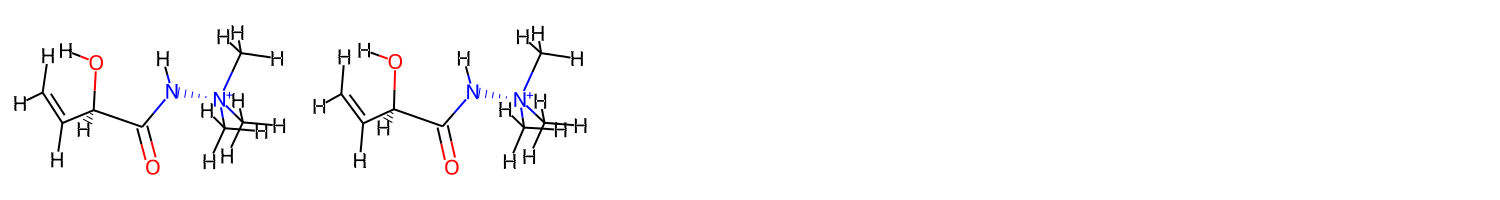

In [23]:
Chem.Draw.MolsToGridImage(mol+mol2, molsPerRow=5,subImgSize=(300,200))

In [24]:
with open("pickled_data/y_h_geom_comp_84.pkl", "wb") as file:
    pickle.dump(mol+mol2, file)

# Generate Ylide-Rad Starting point with Ylide-H optimized solution phase geometry

In [26]:
n=len(atom_coords_solv[2])
mols=[]
start=0
stop=100
for i in tqdm(range(start,stop)):

    try:
        charge=charges[2][i]
        make_xyz_from_array('temp_xyz',atom_coords_solv[2][i],atom_labels[2][i],include_charge=True,charge=charge)
        atoms, charge_read, coordinates = x2m.read_xyz_file('temp_xyz.xyz') 
        mol = x2m.xyz2mol(atoms, coordinates, charge=charge) #Can also use charge read defined on the previous line
        mols.append(mol[0])
        
    except Exception as e:
        #print(atom_labels)
        if 'P' in atom_labels[2][i] or 'S' in atom_labels[2][i]:
            print(f'{i}: MOL CONTAINS S or P')
            
        print(f'{i}: DIDNT WORK,ADDING [Ar]')
        mols.append(Chem.MolFromSmiles('[Ar]'))
        
        exc_type, exc_obj, exc_tb = sys.exc_info()
        fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
        print(e)       
        print(exc_type, fname, exc_tb.tb_lineno)
    
    
if os.path.exists('temp_xyz.xyz'): #clean up temp xyz file
    os.remove('temp_xyz.xyz')
else:
    print("The file does not exist")

 27%|██▋       | 27/100 [00:01<00:30,  2.39it/s]

3: DIDNT WORK,ADDING [Ar]
not enough values to unpack (expected 2, got 1)
<class 'ValueError'> <ipython-input-26-06ee1d111a69> 9


100%|██████████| 100/100 [00:01<00:00, 65.05it/s]

68: DIDNT WORK,ADDING [Ar]
not enough values to unpack (expected 2, got 1)
<class 'ValueError'> <ipython-input-26-06ee1d111a69> 9
72: DIDNT WORK,ADDING [Ar]
not enough values to unpack (expected 2, got 1)
<class 'ValueError'> <ipython-input-26-06ee1d111a69> 9


# Remove H atom to form N radical

In [28]:
#Get the indices of the hydrogen and radicals 
new_ylide_rad_xyz=[]
ylide_count=0
H_remove_index=[]
N_index=[]
for i,m in enumerate(tqdm(mols)):
    
    for atom in m.GetAtoms():
        if atom.GetSymbol() == 'N':
            
            neighbors=atom.GetNeighbors()
            neighbor_symbols=[x.GetSymbol() for x in neighbors]
            
            if 'H' in neighbor_symbols and 'N' in neighbor_symbols and 'C' in neighbor_symbols: #Check that the correct neighbors are connected
                
                for n in neighbors:
                    if n.GetSymbol()=='N':
                        if n.GetFormalCharge()==1: #Make sure the connected N has a formal charge of 1

                            index=neighbor_symbols.index('H')
                            n_index=atom.GetIdx()

                            H_remove_index.append(neighbors[index].GetIdx())
                            N_index.append(n_index)

        if atom.GetSymbol() == 'Ar':
            H_remove_index.append(-1)
            N_index.append(-1)
    

100%|██████████| 100/100 [00:00<00:00, 445.92it/s]


In [29]:
#Remove hydrogen and make N a radical

ylide_rad_opt=[]
for i,h in enumerate(tqdm(H_remove_index)):
    try:
        m=mols[i]
        m2=Chem.rdchem.RWMol(m)
        n_index=N_index[i]
        m2.GetAtomWithIdx(n_index).SetNumRadicalElectrons(1)
        m2.RemoveAtom(h)
        
        ylide_rad_opt.append(m2.GetMol())
        
    except Exception as e:
        print(f'Exception Found with {i}')
        ylide_rad_opt.append(Chem.MolFromSmiles('[Ar]'))
        exc_type, exc_obj, exc_tb = sys.exc_info()
        fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
        print(e)       
        print(exc_type, fname, exc_tb.tb_lineno)

100%|██████████| 100/100 [00:00<00:00, 1551.66it/s]

Exception Found with 3
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-29-971a1143347d> 9
Exception Found with 68
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-29-971a1143347d> 9
Exception Found with 72
can't convert negative value to unsigned int
<class 'OverflowError'> <ipython-input-29-971a1143347d> 9


In [30]:
#Get xyz_coords
ylide_rad_xyz_coords=[]
for i,m in enumerate(tqdm(ylide_rad_opt)):
    try:
        mb=Chem.MolToMolBlock(m)
        xyz=GetCoordsFromMolBlock(mb)
        ylide_rad_xyz_coords.append(xyz)
    except Exception as e:
        print(i)

100%|██████████| 100/100 [00:01<00:00, 65.78it/s]


In [49]:
failed_yh_to_yr

[505,
 581,
 583,
 593,
 594,
 620,
 624,
 655,
 667,
 708,
 775,
 826,
 833,
 848,
 852,
 887,
 970,
 971]

In [50]:
overwrite=True
if overwrite:
    with open("pickled_data/y_rad_from_y_h_xyz_solv.pkl", "wb") as file:
        pickle.dump(ylide_rad_xyz_coords, file)

In [51]:
with open("pickled_data/y_rad_from_y_h_xyz_solv.pkl","rb") as file:
    pickle_off = pickle.Unpickler(file)
    y_rad_from_y_h_solv = pickle_off.load()

# Make xyz files for y_rad gas from from optimized y_h solution geometries

In [52]:
actually_make_dirs=True
if actually_make_dirs:

    z=7
    cwd=os.getcwd()
    calc_folder='Calcs'

    functional='M062X'
    basis= 'Def2TZVP'
    solvorgas='solv'
    solvmethod='SMD'
    solvent='acetonitrile'
    smi_dict={''    :y,
          '_rad' : yr,
          '_h'   : yh
         }
    suffix= ['_rad']
    for i, s in enumerate(tqdm(range(100))):

        assert solvorgas == 'gas' or solvorgas=='solv','SOLVORGAS NOT SET TO A VALID VALUE'
        
        for j, suff in enumerate(suffix): 


            if solvorgas=='gas':

                basepath=f'{cwd}/{calc_folder}/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/gas'

            elif solvorgas=='solv':

                try:
                    solvent
                except NameError:
                    raise Exception('PLEASE SPECIFY A SOLVENT')


                basepath=f'{cwd}/{calc_folder}/{str(i).zfill(z)}/ylide{suff}/{functional}/{basis}/{solvent}/{solvmethod}'


            os.makedirs(basepath,exist_ok=True)


            smi= smi_dict[suff][i]
            path=f'{basepath}/{str(i).zfill(z)}_ylide{suff}'

            try:        
                #mk_smi_file(smi,path)
                write_xyz_from_xyz_arr(y_rad_from_y_h_solv[i],f'{path}_y_h_opt')
                mkgauss_input_from_xyz(f'{path}_y_h_opt',smi,functional=functional,basis=basis,solvorgas=solvorgas,solvmethod=solvmethod,solvent=solvent)
                mkgauss_submission_script(f'{path}_y_h_opt')
            except Exception as e:
                print(e)
                exc_type, exc_obj, exc_tb = sys.exc_info()
                fname = os.path.split(exc_tb.tb_frame.f_code.co_filename)[1]
                print(exc_type, fname, exc_tb.tb_lineno)
                print(f'ERROR WITH  MOLECULE NUMBER {i} smiles {path}')

100%|██████████| 100/100 [00:11<00:00,  8.53it/s]
